Epoch [1/20], Train Loss: 1.4005, Train Acc: 26.77%, Val Loss: 1.3810, Val Acc: 27.40%


Epoch [2/20], Train Loss: 0.9417, Train Acc: 57.04%, Val Loss: 0.6927, Val Acc: 72.00%


Epoch [3/20], Train Loss: 0.4678, Train Acc: 83.43%, Val Loss: 0.3868, Val Acc: 86.52%


Epoch [4/20], Train Loss: 0.3191, Train Acc: 89.57%, Val Loss: 0.3484, Val Acc: 88.42%


Epoch [5/20], Train Loss: 0.2650, Train Acc: 91.58%, Val Loss: 0.3152, Val Acc: 89.46%


...

Epoch [17/20], Train Loss: 0.0738, Train Acc: 98.07%, Val Loss: 0.5948, Val Acc: 88.97%


Epoch [18/20], Train Loss: 0.0706, Train Acc: 98.12%, Val Loss: 0.4875, Val Acc: 89.00%


Epoch [19/20], Train Loss: 0.0710, Train Acc: 98.21%, Val Loss: 0.7206, Val Acc: 88.62%


Epoch [20/20], Train Loss: 0.0640, Train Acc: 98.36%, Val Loss: 0.7863, Val Acc: 89.00%


Test Accuracy: 88.46%


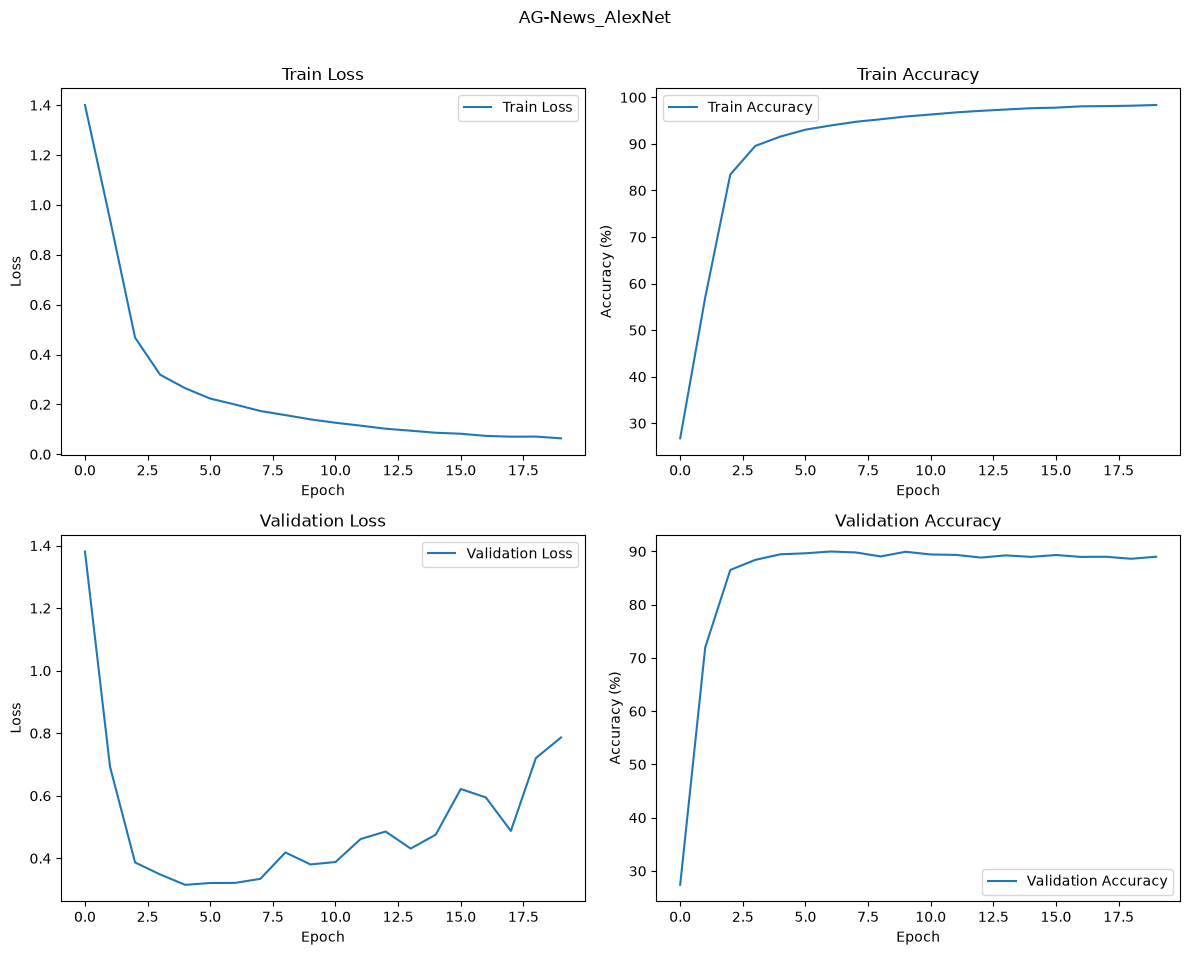

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

run_name = 'AG-News_AlexNet'

# Text converges (and overfits) much faster than the image benchmarks
num_epochs = 20
batch_size = 128
learning_rate = 0.001

import csv
import os
import re
import urllib.request
from collections import Counter

max_len = 64
embed_dim = 64
vocab_limit = 50000

# Download AG News (4-class news topic classification)
base_url = 'https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/'
os.makedirs('./data/ag_news', exist_ok=True)
for split in ['train', 'test']:
    path = f'./data/ag_news/{split}.csv'
    if not os.path.exists(path):
        print(f'Downloading {split}.csv...')
        urllib.request.urlretrieve(base_url + f'{split}.csv', path)

def load_split(path):
    texts, labels = [], []
    with open(path, encoding='utf-8') as f:
        for row in csv.reader(f):
            labels.append(int(row[0]) - 1)
            texts.append((row[1] + ' ' + row[2]).lower())
    return texts, labels

train_texts, train_labels = load_split('./data/ag_news/train.csv')
test_texts, test_labels = load_split('./data/ag_news/test.csv')

def tokenize(text):
    return re.findall(r"[a-z0-9']+", text)

# Build vocabulary from the training split
counter = Counter()
for text in train_texts:
    counter.update(tokenize(text))

vocab = {'<pad>': 0, '<unk>': 1}
for word, _ in counter.most_common(vocab_limit - 2):
    vocab[word] = len(vocab)

def encode(text):
    ids = [vocab.get(tok, 1) for tok in tokenize(text)][:max_len]
    ids += [0] * (max_len - len(ids))
    return ids

class AGNewsDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.data = torch.tensor([encode(t) for t in texts], dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

train_dataset = AGNewsDataset(train_texts, train_labels)
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

test_dataset = AGNewsDataset(test_texts, test_labels)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Hybrid Initialization (He for Conv2d, Orthogonal for Linear)
def custom_init(model):
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
        elif isinstance(module, nn.Linear):
            nn.init.orthogonal_(module.weight)
        if hasattr(module, 'bias') and module.bias is not None:
            nn.init.constant_(module.bias, 0)

# AlexNet over the embedded token map, treated as a 1-channel image
# (first conv adapted to 1 channel, same pattern as the QMNIST notebook)
class AlexNetText(nn.Module):
    def __init__(self):
        super(AlexNetText, self).__init__()

        self.embedding = nn.Embedding(len(vocab), embed_dim, padding_idx=0)
        self.alexnet = models.alexnet(weights=None)

        self.alexnet.features[0] = nn.Conv2d(1, 64, kernel_size=11, stride=4, padding=2)
        self.alexnet.classifier[6] = nn.Linear(4096, 4)

    def forward(self, x):
        x = self.embedding(x)
        x = x.unsqueeze(1)
        return self.alexnet(x)

model = AlexNetText().to(device)
custom_init(model)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_loss_list = []
train_acc_list = []
val_loss_list = []
val_acc_list = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    val_loss_list.append(val_loss / len(val_loader))
    val_acc_list.append(val_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss_list[-1]:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss_list[-1]:.4f}, Val Acc: {val_acc:.2f}%')

correct = 0
total = 0
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f'Test Accuracy: {test_acc:.2f}%')

# Save metrics to files labelled with dataset + model name
with open(f'{run_name}_metrics.csv', 'w') as f:
    f.write('epoch,train_loss,train_acc,val_loss,val_acc\n')
    for i in range(num_epochs):
        f.write(f'{i+1},{train_loss_list[i]:.6f},{train_acc_list[i]:.4f},{val_loss_list[i]:.6f},{val_acc_list[i]:.4f}\n')

with open(f'{run_name}_test_accuracy.txt', 'w') as f:
    f.write(f'{run_name} Test Accuracy: {test_acc:.2f}%\n')

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(train_acc_list, label='Train Accuracy')
plt.title('Train Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(val_loss_list, label='Validation Loss')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(val_acc_list, label='Validation Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.suptitle(run_name)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig(f'{run_name}_curves.png', dpi=150)
plt.show()